# Большое исследование данных. 

- Автор: Бышин М.И. (hh.ru/resume/3a27e4d7ff0ef40ab90039ed1f6f445a567078)

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Загрузка данных

#### Комментарий:
- Решил детальнее познакомиться с данными, поэтому некоторые пункты в предобработке можно было бы не делать или удалить. Оставил их для понимания хода размышлений.
- Делал упор на комментирование каждого шага и описания логики кода. 

In [ ]:
# Так как, нам известен формат файла, то загружаем его сразу по заданным параметрам
file_path = 'C:/Users/Downloads/Matrix.csv' # МОЯ ДИРЕКТОРИЯ С ФАЙЛОМ
encoding = 'utf-8'
sep = ';'
lineterminator = '\n'

# Загружаем
matrix = pd.read_csv(
    file_path,
    encoding=encoding,
    sep=sep,
    lineterminator=lineterminator,
    header=0  # Используем первую строку как заголовок
)

In [3]:
# Знакомимся
matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191345852 entries, 0 to 191345851
Data columns (total 5 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   ts                   object
 1   departure_zid        int64 
 2   arrival_zid          int64 
 3   customers_cnt        int64 
 4   customers_cnt_metro  int64 
dtypes: int64(4), object(1)
memory usage: 7.1+ GB


In [4]:
# Визуально осматриваем
display(matrix)

,ts,departure_zid,arrival_zid,customers_cnt,customers_cnt_metro
0,2014.08.01 00:00,914,914,17,0
1,2014.08.01 00:00,914,915,11,1
2,2014.08.01 00:00,914,615,1,0
3,2014.08.01 00:00,914,208,1,0
4,2014.08.01 00:00,914,1174,1,0
...,...,...,...,...,...
191345847,2014.08.31 23:30,1475,888,1,0
191345848,2014.08.31 23:30,1475,966,1,0
191345849,2014.08.31 23:30,1475,59,5,0
191345850,2014.08.31 23:30,1475,1157,8,0


##### Предварительная оценка качества данных
- Датафрейм загружен.
- Названия полей корректны.
- Меняем тип данных в столбце `ts` на `datetime64`.
- Для оптимизации времени отработки кода меням тип данных во всех остальных столбцах на `int16`(Опциональное решение, если того требует задача).
- Возможно, будет необходимость предобрабоать пропуски и дубликаты в данных. Позже ответим на этот вопрос.

### Предобработка данных

##### Преобразование форматов данных

In [5]:
# Преобразование формата
matrix['ts'] = pd.to_datetime(matrix['ts']) # Меянем на datetime

In [6]:
# Функция для преобразование формата в остальных столбцах
def convert_to_int16(df):
    """
    Преобразует все столбцы в тип int16
    """
    # Создаем словарь для всех столбцов кроме ts
    columns_to_convert = [col for col in df.columns if col != 'ts'] # Коме ts
    dtype_dict = {col: 'int16' for col in columns_to_convert}
    
    # Применяем преобразование
    return df.astype(dtype_dict)

# Применяем функцию к датафрейму
matrix = convert_to_int16(matrix)

In [7]:
# Проверяем результат
matrix.dtypes

ts                     datetime64[ns]
departure_zid                   int16
arrival_zid                     int16
customers_cnt                   int16
customers_cnt_metro             int16
dtype: object

In [8]:
# Ещё раз визуально осматриваем
display(matrix)

,ts,departure_zid,arrival_zid,customers_cnt,customers_cnt_metro
0,2014-08-01 00:00:00,914,914,17,0
1,2014-08-01 00:00:00,914,915,11,1
2,2014-08-01 00:00:00,914,615,1,0
3,2014-08-01 00:00:00,914,208,1,0
4,2014-08-01 00:00:00,914,1174,1,0
...,...,...,...,...,...
191345847,2014-08-31 23:30:00,1475,888,1,0
191345848,2014-08-31 23:30:00,1475,966,1,0
191345849,2014-08-31 23:30:00,1475,59,5,0
191345850,2014-08-31 23:30:00,1475,1157,8,0


##### Анализ дубликатов данных

In [9]:
# Проверяем наличие явных дубликатов
sum_dup = matrix.duplicated().sum()
print(f'{sum_dup} дубликатов в датасете.')

0 дубликатов в датасете.


- Поиск "неявных" дубликатов смысла не имеет.

##### Анализ пропусков(на всякий случай)

In [10]:
nulls = matrix.isna().sum()
print("Пропуски по колонкам:")
print(nulls)

Пропуски по колонкам:
ts                     0
departure_zid          0
arrival_zid            0
customers_cnt          0
customers_cnt_metro    0
dtype: int64


## Задание № 1
Предположим, что территория города разделена на непересекающиеся зоны. Имеется матрица корреспонденций, содержащая информацию о числе поездок между каждой парой зон города, за каждые полчаса в течение календарного месяца. Формат файла с матрицей Matrix.csv приведен ниже.

- 1.1 Под часом пик будем понимать период наибольшей нагрузки на транспортную инфраструктуру города. Вообще говоря, продолжительность часа пик не равна астрономическому часу. Напишите программу, получающую на вход указанный файл и определяющую утренний и вечерний часы пик буднего дня: как для каждой отдельной зоны, так и для всего города в целом.
- 1.2 Какие полезные с точки зрения развития города показатели можно извлечь из предложенной матрицы? Если программно реализуете их вычисление, то это будет дополнительным плюсом.
- 1.3 Имеется файл Zones.csv, где все зоны города объединены в районы города следующим образом: каждый район является объединением нескольких зон, при этом разные районы не пересекаются. Пример содержимого файла Zones.csv (здесь зоны 1, 2 объединены в район 1, зоны 3, 4 – в район 2, а зона 5 совпадает с районом 3). Напишите программу, получающую на вход файлы Matrix.csv и Zones.csv, результатом работы
которой является матрица корреспонденций между районами города, за каждые полчаса в течение
календарного месяца.

**В заданиях этого нет, но где это возможно, строил визуализации для лучшего понимания и интерпретации результатов исследования.**

### Задача 1.1 (с городом в целом)

#### Логика решения подзадачи с определением часов пик для города в целом:

1. **Подготовка данных**:
   - Добавляем временные признаки (час, минута, день недели)
   - Фильтруем только будние дни

2. **Анализ нагрузки по минутам**:
   - Группируем данные по часам и минутам
   - Строим линейный график нагрузки в течение дня

3. **Анализ 30-минутных интервалов**:
   - Создаем 30-минутные интервалы
   - Агрегируем данные по этим интервалам
   - Визуализируем в виде столбчатой диаграммы

4. **Определение часов пик**:
   - Для утра (5:00-11:00) находим 3 интервала с максимальной нагрузкой
   - Для вечера (15:00-22:00) находим 3 интервала с максимальной нагрузкой
   - Выводим результаты в удобочитаемом формате

5. **Визуализация**:
   - Все графики имеют подписи и сетку для лучшей читаемости
   - Для удобства чтения результаты выводятся с понятными названиями столбцов, а так-же убраны технические индексы строк из вывода

2 минуты

In [9]:
# Добавим дополнительные временные признаки
matrix['hour'] = matrix['ts'].dt.hour
matrix['minute'] = matrix['ts'].dt.minute
matrix['day_of_week'] = matrix['ts'].dt.dayofweek  # 0-понедельник, 6-воскресенье
matrix['date'] = matrix['ts'].dt.date

# Отфильтруем только будние дни (пн-пт, где dayofweek 0-4)
weekdays = matrix[matrix['day_of_week'] < 5].copy()

##### Определение часов пик для всего города

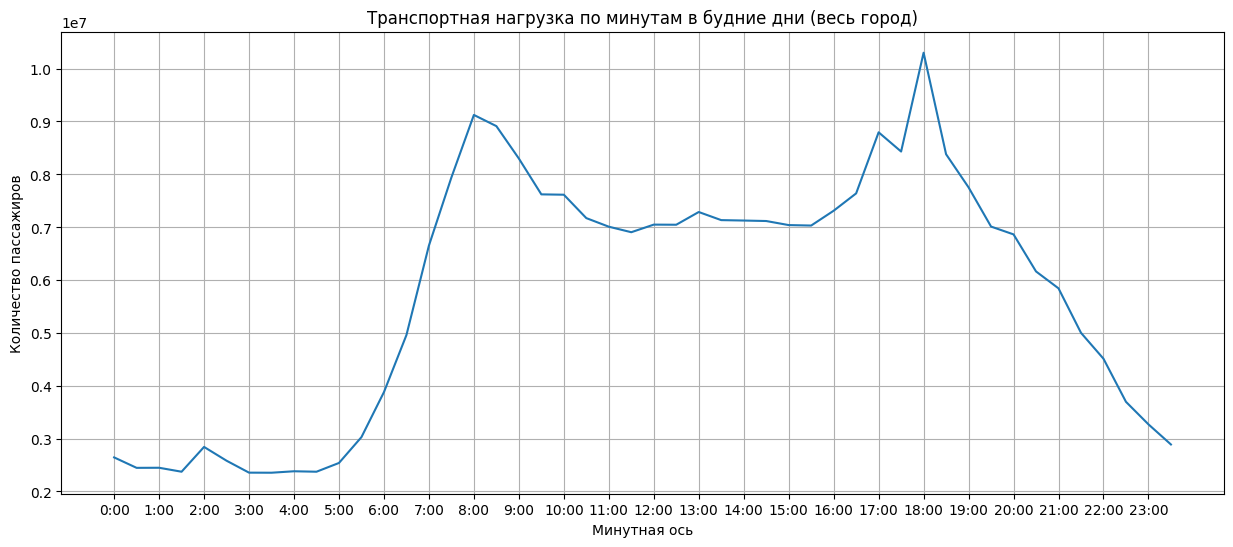

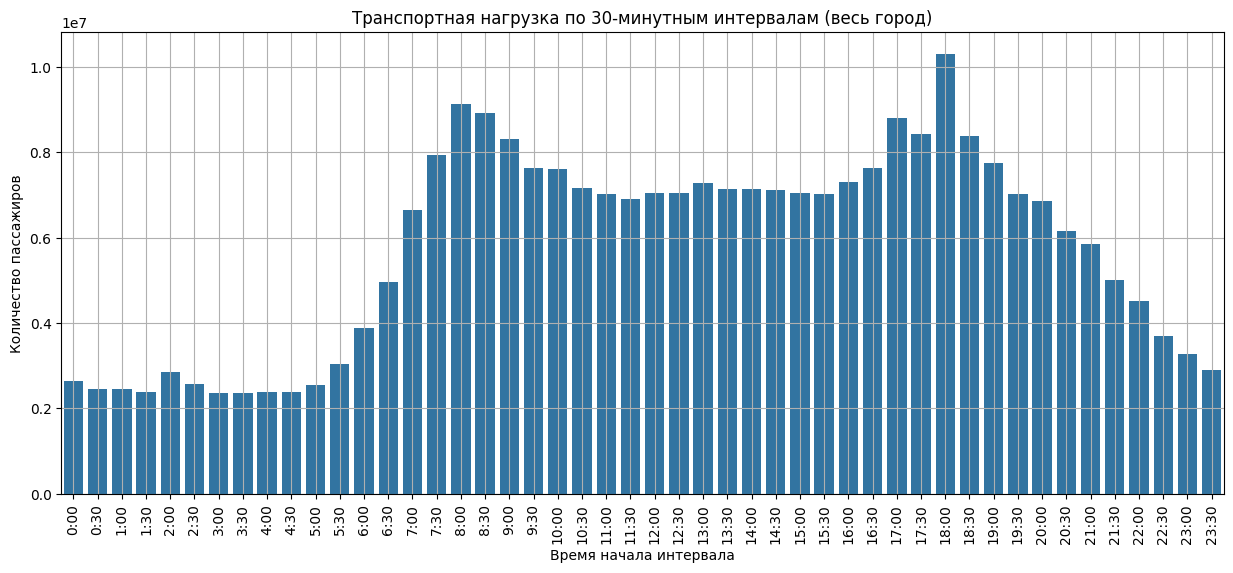

Утренний час пик для всего города:
Время  Кол-во пассажиров
 8:00            9123125
 8:30            8911567
 9:00            8298676

Вечерний час пик для всего города:
Время  Кол-во пассажиров
18:00           10300099
17:00            8794346
17:30            8430736


In [12]:
# Агрегируем данные по временным интервалам для всего города
city_peak = weekdays.groupby(['hour', 'minute']).agg({  # Группируем данные по часам и минутам
    'customers_cnt': 'sum'  # Суммируем количество пассажиров
}).reset_index()  # Сбрасываем индекс для работы с данными

# Переведем часы и минуты в минуты для удобства визуализации
city_peak['time_in_minutes'] = city_peak['hour'] * 60 + city_peak['minute']  # Создаем колонку с минутами

# Визуализация
plt.figure(figsize=(15, 6)) 
sns.lineplot(data=city_peak, x='time_in_minutes', y='customers_cnt')  # Строим линейный график
plt.title('Транспортная нагрузка по минутам в будние дни (весь город)') 
plt.xlabel('Минутная ось') 
plt.ylabel('Количество пассажиров')  
plt.xticks(np.arange(0, 1440, 60), [f'{h}:00' for h in range(24)])  # Разметка оси X каждый час
plt.grid(True)  # Включаем сетку
plt.show() 

# Находим утренний и вечерний часы пик (три последовательных 30-мин интервала с максимальной нагрузкой)

# Агрегируем по 30-мин интервалам
city_30min = weekdays.copy()  # Создаем копию данных
city_30min['time_30min'] = (city_30min['hour'] * 2 + (city_30min['minute'] >= 30).astype(int))  # Создаем 30-мин интервалы

city_30min_agg = city_30min.groupby('time_30min').agg({  # Группируем по 30-мин интервалам
    'customers_cnt': 'sum'  # Суммируем кол-во пассажиров
}).reset_index()  # Сбрасываем индекс

# Переведем обратно в часы
city_30min_agg['hour'] = city_30min_agg['time_30min'] // 2  # Вычисляем час
city_30min_agg['minute'] = (city_30min_agg['time_30min'] % 2) * 30  # Вычисляем минуты 0 или 30
city_30min_agg['time_str'] = city_30min_agg['hour'].astype(str) + ':' + city_30min_agg['minute'].astype(str).str.zfill(2)  # Форматируем время

# Визуализация
plt.figure(figsize=(15, 6))
sns.barplot(data=city_30min_agg, x='time_str', y='customers_cnt')  # Строим столбчатую диаграмму
plt.title('Транспортная нагрузка по 30-минутным интервалам (весь город)') 
plt.xlabel('Время начала интервала') 
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=90)  # Поворачиваем подписи для удобства
plt.grid(True)
plt.show()

# Найдем топ-3 интервала для утра 5:00-11:00 и вечера 15:00-22:00)\
morning_peak = city_30min_agg[  # Фильтруем утренние часы
    (city_30min_agg['hour'] >= 5) & (city_30min_agg['hour'] < 11)
].nlargest(3, 'customers_cnt')  # Берем 3 интервала с максимальной нагрузкой

evening_peak = city_30min_agg[  # Фильтруем вечерние часы
    (city_30min_agg['hour'] >= 15) & (city_30min_agg['hour'] < 22)
].nlargest(3, 'customers_cnt')  # Берем 3 интервала с максимальной нагрузкой

# Готовим данные для вывода
morning_peak_display = morning_peak.rename(columns={  # Переименовываем колонки для удобства чтения
    'time_str': 'Время',  
    'customers_cnt': 'Кол-во пассажиров'  
})[['Время', 'Кол-во пассажиров']] 

evening_peak_display = evening_peak.rename(columns={  # Аналогично для вечерних часов
    'time_str': 'Время',
    'customers_cnt': 'Кол-во пассажиров'
})[['Время', 'Кол-во пассажиров']]

# Выводим результаты с новыми названиями столбцов
print("Утренний час пик для всего города:")
print(morning_peak_display.to_string(index=False))  # Вывод без индексов

print("\nВечерний час пик для всего города:")
print(evening_peak_display.to_string(index=False))  # Вывод без индексов

### Задача 1.1 (с зонами города)

#### Логика решения:

1. **Анализ нагрузки по зонам**:
   - Для каждой зоны анализируется количество уехавших и приехавших пассажиров
   - Данные агрегируются по 30-минутным интервалам для выявления пиковых периодов

2. **Определение часов пик**:
   - Утренние часы пик: 5:00-11:00 (топ-3 интервала)
   - Вечерние часы пик: 15:00-22:00 (топ-3 интервала)
   - Для каждого интервала сохраняется общее количество пассажиров и разделение на отправления/прибытия

3. **Ранжирование зон**:
   - Зоны сортируются по общему количеству пассажиров (отправления + прибытия)
   - Выделяются топ-5 самых загруженных зон для визуализации (это число меняется в коде)

4. **Визуализация и отчетность**:
   - Строятся графики нагрузки для топ-5 зон
   - Формируются таблицы с пиковыми периодами
   - Выводится общая статистика по всем зонам
   - Все столбцы переименованы на понятные названия
   - Так как, запрос выполняется долго, то добавил визуализацию прогресса обработки. У моего ПК ушло около 9 минут.

#### Определение часов пик для отдельных зон

In [13]:
# Подсчитываем количество зон
unique_count_departure = matrix['departure_zid'].nunique()
unique_count_arrival = matrix['arrival_zid'].nunique()

print(f"Количество уникальных значений в столбце 'departure_zid': {unique_count_departure}")
print(f"Количество уникальных значений в столбце 'arrival_zid': {unique_count_arrival}")

Количество уникальных значений в столбце 'departure_zid': 1405
Количество уникальных значений в столбце 'arrival_zid': 1405


**Комментраий:**
- В задаче требуется написать скрипт для определения часов пик для каждой из зон. Всего их 1405. Думаю, что не имеет смысла выводить все 1405 графиков + краткую статистику(как в предыдущей задаче с городом). При этом, код обработает все 1405 зон и выведет ТОП-5 самых загруженных. Этот параметр вариативен, можно вывести ТОП-10, ТОП-100 и тд, хоть, все ТОП-1405 графиков. В коде оставлю пометку, где этот параметр можно изменить, написав необходимое число. 
- Плюс, решил добавить на график параметр `total` загрузки(departure_zid + arrival_zid).
- Была мысль добавить функцию выбора конкретной зоны, если актуально, то реализую.

Всего уникальных зон: 1405
Сбор данных по всем зонам...
Обработано 100 зон из 1405
Обработано 200 зон из 1405
Обработано 300 зон из 1405
Обработано 400 зон из 1405
Обработано 500 зон из 1405
Обработано 600 зон из 1405
Обработано 700 зон из 1405
Обработано 800 зон из 1405
Обработано 900 зон из 1405
Обработано 1000 зон из 1405
Обработано 1100 зон из 1405
Обработано 1200 зон из 1405
Обработано 1300 зон из 1405
Обработано 1400 зон из 1405

Топ-5 самых загруженных зон:
     ID зоны  Общее кол-во пассажиров
650      650                  3624626
357      357                  3358150
179      179                  3134142

Визуализация для топ-5 зон...


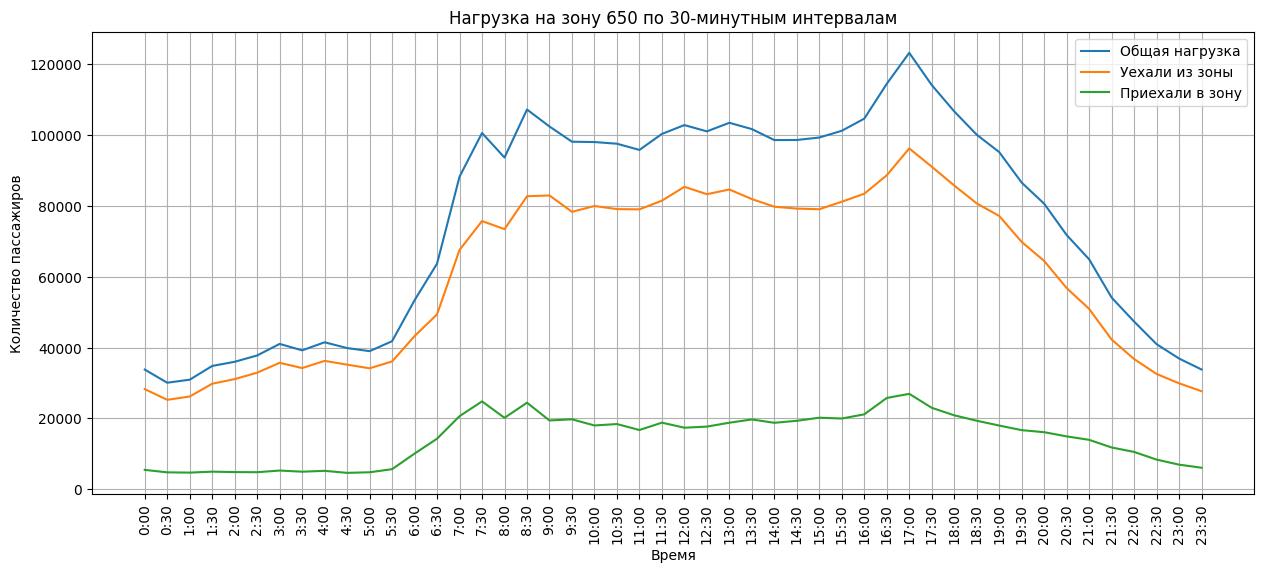


Анализ для зоны 650 (топ-5):
Утренний час пик:
Время  Общее кол-во пассажиров  Уехали из зоны  Приехали в зону
 8:30                   107124           82669            24455
 9:00                   102336           82892            19444
 7:30                   100496           75670            24826

Вечерний час пик:
Время  Общее кол-во пассажиров  Уехали из зоны  Приехали в зону
17:00                   123101           96146            26955
16:30                   114372           88581            25791
17:30                   114022           91002            23020


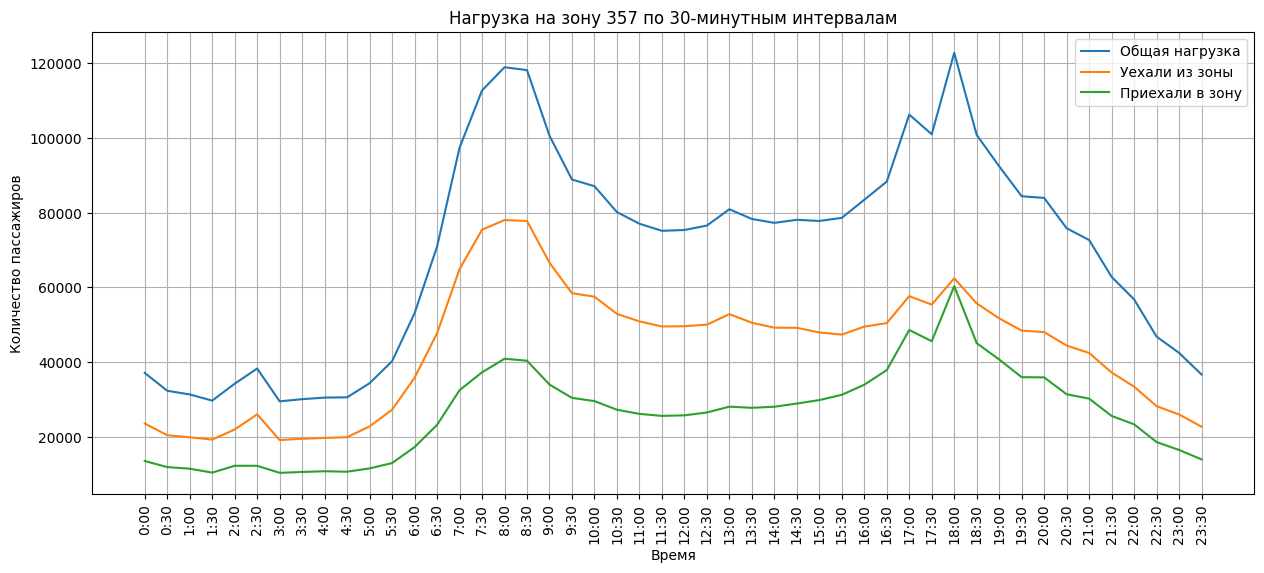


Анализ для зоны 357 (топ-5):
Утренний час пик:
Время  Общее кол-во пассажиров  Уехали из зоны  Приехали в зону
 8:00                   118909           78016            40893
 8:30                   118139           77772            40367
 7:30                   112695           75432            37263

Вечерний час пик:
Время  Общее кол-во пассажиров  Уехали из зоны  Приехали в зону
18:00                   122761           62432            60329
17:00                   106237           57649            48588
17:30                   100972           55385            45587


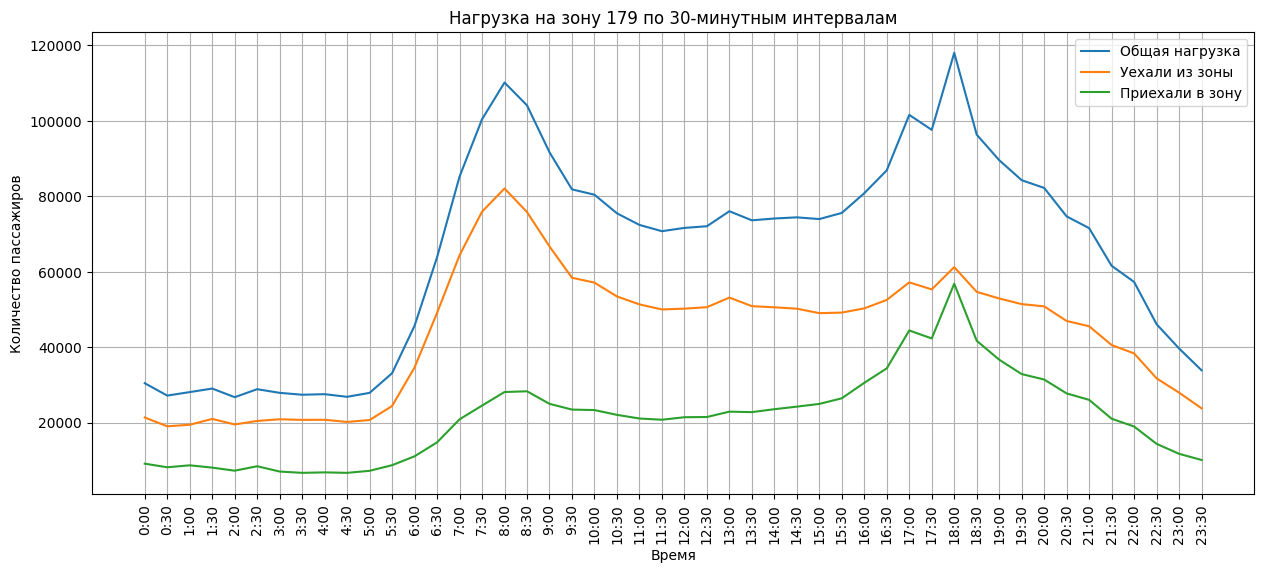


Анализ для зоны 179 (топ-5):
Утренний час пик:
Время  Общее кол-во пассажиров  Уехали из зоны  Приехали в зону
 8:00                   110089           82012            28077
 8:30                   104047           75773            28274
 7:30                   100350           75867            24483

Вечерний час пик:
Время  Общее кол-во пассажиров  Уехали из зоны  Приехали в зону
18:00                   117957           61172            56785
17:00                   101520           57132            44388
17:30                    97549           55274            42275

Общая статистика по зонам:
Всего проанализировано зон: 1405
Средняя нагрузка пассажиров на зону : 344634.9
Максимальная нагрузка: 3624626 (зона 650)
Минимальная нагрузка: 2 (зона 483)


In [14]:
# Функция для анализа транспортной нагрузки в конкретной зоне
def analyze_zone(zone_id, data):
    # Фильтруем данные только для указанной зоны (как отправления, так и прибытия)
    zone_data = data[(data['departure_zid'] == zone_id) | (data['arrival_zid'] == zone_id)].copy()
    # Если для зоны нет данных, возвращаем None
    if zone_data.empty:
        return None
        
    # Создаем столбец направления - отмечаем отъезды из зоны и прибытия в зону
    zone_data['direction'] = np.where(zone_data['departure_zid'] == zone_id, 'departure', 'arrival')
    # Создаем копию данных для работы с 30-минутными интервалами
    zone_30min = zone_data.copy()   
    # Создаем числовой идентификатор 30-минутного интервала (0=0:00-0:29, 1=0:30-0:59 и т.д.)
    zone_30min['time_30min'] = (zone_30min['hour'] * 2 + (zone_30min['minute'] >= 30).astype(int)) 
    # Группируем данные по интервалам и направлениям, суммируя количество пассажиров
    zone_agg = zone_30min.groupby(['time_30min', 'direction'])['customers_cnt'].sum().unstack(fill_value=0)
    # Добавляем столбец с общим количеством пассажиров (прибытия + отправления)
    zone_agg['total'] = zone_agg.sum(axis=1)
    # Вычисляем час из идентификатора интервала
    zone_agg['hour'] = zone_agg.index // 2
    # Вычисляем минуты (0 или 30) из идентификатора интервала
    zone_agg['minute'] = (zone_agg.index % 2) * 30
    # Создаем строковое представление времени в формате HH:MM
    zone_agg['time_str'] = zone_agg['hour'].astype(str) + ':' + zone_agg['minute'].astype(str).str.zfill(2)
    return zone_agg
    
# Ещё раз получаем список всех уникальных зон
all_zones = pd.concat([weekdays['departure_zid'], weekdays['arrival_zid']]).unique()
print(f"Всего уникальных зон: {len(all_zones)}")

# Создаем словарь для хранения результатов анализа по зонам
zone_results = {}

# Начинаем сбор данных по всем зонам
print("Сбор данных по всем зонам...")

# Перебираем все зоны с отслеживанием прогресса
for i, zone in enumerate(all_zones):
    try:
        # Анализируем текущую зону
        zone_data = analyze_zone(zone, weekdays)
        # Пропускаем зоны без данных
        if zone_data is None:
            continue    
        # Находим 3 самых загруженных утренних интервала (5:00-11:00)
        morning_peak = zone_data[
            (zone_data['hour'] >= 5) & (zone_data['hour'] < 11)
        ].nlargest(3, 'total')
        # Находим 3 самых загруженных вечерних интервала (15:00-22:00)
        evening_peak = zone_data[
            (zone_data['hour'] >= 15) & (zone_data['hour'] < 22)
        ].nlargest(3, 'total') 
        # Сохраняем результаты с переименованными столбцами
        zone_results[zone] = {
            # Утренние часы пик с переименованными столбцмаи
            'morning_peak': morning_peak.rename(columns={
                'time_str': 'Время',
                'total': 'Общее кол-во пассажиров',
                'departure': 'Уехали из зоны',
                'arrival': 'Приехали в зону'
            })[['Время', 'Общее кол-во пассажиров', 'Уехали из зоны', 'Приехали в зону']].to_dict('records'),
            # Вечерние часы пик с переименованными столбцами
            'evening_peak': evening_peak.rename(columns={
                'time_str': 'Время',
                'total': 'Общее кол-во пассажиров',
                'departure': 'Уехали из зоны',
                'arrival': 'Приехали в зону'
            })[['Время', 'Общее кол-во пассажиров', 'Уехали из зоны', 'Приехали в зону']].to_dict('records'),
            # Общее количество пассажиров за все время
            'total_traffic': zone_data['total'].sum(),
            # Все данные по зоне для визуализации
            'zone_data': zone_data
        } 
        # Выводим прогресс обработки каждые 100 зон для нагладности
        if (i+1) % 100 == 0:
            print(f"Обработано {i+1} зон из {len(all_zones)}")  
            
    # Возможные ошибки
    except Exception as e:
        print(f"Ошибка при анализе зоны {zone}: {str(e)}")
        
# Преобразуем словарь в датафрейм
results_df = pd.DataFrame.from_dict(zone_results, orient='index')

# Переименовываем столбцы для итогового отчета
results_df['ID зоны'] = results_df.index
results_df = results_df.rename(columns={
    'total_traffic': 'Общее кол-во пассажиров'
})[['ID зоны', 'Общее кол-во пассажиров', 'morning_peak', 'evening_peak', 'zone_data']]

# Определяем ТОП-5 самых загруженных зон по общему количеству пассажиров
top_5_zones = results_df.nlargest(3, 'Общее кол-во пассажиров').index.tolist() # ТУТ МЕНЯЕМ ЧИСЛО ЗОН ДЛЯ ВИЗУАЛИЗАЦИИ
print("\nТоп-5 самых загруженных зон:")
print(results_df.nlargest(3, 'Общее кол-во пассажиров')[['ID зоны', 'Общее кол-во пассажиров']]) # ТУТ МЕНЯЕМ ЧИСЛО ЗОН ДЛЯ ВИЗУАЛИЗАЦИИ

# Визуализируем данные для топ-5 зон
print("\nВизуализация для топ-5 зон...")

for zone in top_5_zones:
    # Получаем данные для визуализации
    zone_data = zone_results[zone]['zone_data'] 
    # Создаем график
    plt.figure(figsize=(15, 6))
    # Добавляем линии на график
    sns.lineplot(data=zone_data, x='time_str', y='total', label='Общая нагрузка')
    sns.lineplot(data=zone_data, x='time_str', y='departure', label='Уехали из зоны')
    sns.lineplot(data=zone_data, x='time_str', y='arrival', label='Приехали в зону')
    # Настраиваем график
    plt.title(f'Нагрузка на зону {zone} по 30-минутным интервалам')
    plt.xlabel('Время')
    plt.ylabel('Количество пассажиров')
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(True)
    plt.show()
    
  # Выводим таблицы с пиковыми периодами
    print(f"\nАнализ для зоны {zone} (топ-5):")
    print("Утренний час пик:")
    print(pd.DataFrame(zone_results[zone]['morning_peak']).to_string(index=False))
    print("\nВечерний час пик:")
    print(pd.DataFrame(zone_results[zone]['evening_peak']).to_string(index=False))
    
# Выводим общую статистику по всем зонам
print("\nОбщая статистика по зонам:")
print(f"Всего проанализировано зон: {len(results_df)}")
print(f"Средняя нагрузка пассажиров на зону : {results_df['Общее кол-во пассажиров'].mean():.1f}")
print(f"Максимальная нагрузка: {results_df['Общее кол-во пассажиров'].max()} (зона {results_df['Общее кол-во пассажиров'].idxmax()})")
print(f"Минимальная нагрузка: {results_df['Общее кол-во пассажиров'].min()} (зона {results_df['Общее кол-во пассажиров'].idxmin()})")

### Задача 1.2

##### **Коэффициент притока/оттока зоны**:
- Показывает баланс зоны(отток/приток).
- если > 0, то это зоны-магниты (работы/учёбы)
- если < 0, то это жилые зоны(скорее всего)

In [15]:
# Коэффициент баланса зоны
def balance_ratio(matrix):
    """
    Анализирует соотношение входящего и исходящего трафика зоны.
    Функция для сравненяи оттока vs притока.
    """
    # Суммарный отток из зоны
    outflow = matrix.groupby('departure_zid')['customers_cnt'].sum().reset_index()  
    outflow.columns = ['Зона', 'Уехали']  # Переименовываем колонки для удобства чтения
    
    # Суммарный приток в зону
    inflow = matrix.groupby('arrival_zid')['customers_cnt'].sum().reset_index()  
    inflow.columns = ['Зона', 'Приехали'] # Переименовываем колонки для удобства чтения
    
    # Объединяем приток и отток
    balance = pd.merge(outflow, inflow, on='Зона', how='outer').fillna(0)  
    # Вычисляем коэффициент баланса: (приток - отток) / общий трафик
    balance['Доля'] = (balance['Приехали'] - balance['Уехали']) / (balance['Приехали'] + balance['Уехали'] + 1e-6)  
    
    return balance.sort_values('Доля', ascending=False)

# Применяем функцию:
balance = balance_ratio(matrix)

# Смотрим результат
print("\nЗоны с наибольшим притоком (Доля > 0):")
print(balance[balance['Доля'] > 0].head()) # ТУТ МОЖНО ПОМЕНЯТЬ ЧИСЛО ВЫВОДИМЫХ ЗОН
print("\nЗоны с наибольшим оттоком (Доля < 0):")
print(balance[balance['Доля'] < 0].head()) # ТУТ МОЖНО ПОМЕНЯТЬ ЧИСЛО ВЫВОДИМЫХ ЗОН


Зоны с наибольшим притоком (Доля > 0):
      Зона  Уехали  Приехали      Доля
1297  1387   81689    187599  0.393296
558    603   31509     65998  0.353708
909    980  255434    494663  0.318931
946   1018   54853     92279  0.254370
851    920   88301    141791  0.232472

Зоны с наибольшим оттоком (Доля < 0):
      Зона  Уехали  Приехали      Доля
696    752  264190    264180 -0.000019
784    847  756760    756720 -0.000026
1223  1309   46615     46612 -0.000032
1382  1474  432833    432790 -0.000050
457    497  210191    210169 -0.000052


**Интерпретация**:  
**Зоны с наибольшим притоком**, это: "магниты" дневной активности, это скорее всего офисные центры, университеты и тд.  
- Зона 1387: приток почти в 2.3 раза больше оттока (Доля=0.39).  
- Коэффициент 0.3-0.4 означает, что утром сюда едут на работу/учебу, а вечером уезжают.  
**Что дальше?**:  
- Увеличить транспортную доступность в часы пик (дополнительные автобусы/метро).  
- Развивать инфраструктуру для прибывания а дневное время суток (кафе, парковки).
 
**Зоны с наибольшим оттоком**, это: жилые районы с почти нулевым балансом — отток и приток почти равны.  
- Минимальные значения (-0.00005) показывают, что разница статистически незначима.  
- Зона 847: 756K выезжающих утром и столько же возвращающихся вечером.  
**Что дальше?**:  
- Оптимизировать утренние/вечерние маршруты из этих зон.

##### **Индекс пиковости:** 
- Показывает долю "пиковой нагрузки" от общего трафика на зону. Чем выше индекс, тем более резкий наплыв пассажиров испытывает зона в часы пик.

In [16]:
# Индекс пиковости
def peak_index(zone_results):
    """
    Оценивает, какая доля от общего трафика приходится на часы пик.
    Функция для выявления зон с высокой нагрузкой в часы пик.
    """
    peak_data = []
    for zid, data in zone_results.items():
        # Сумма трафика в утренние часы пик (5:00-11:00)
        morning_peak = sum([x['Общее кол-во пассажиров'] for x in data['morning_peak']])  
        # Сумма трафика в вечерние часы пик (15:00-22:00)
        evening_peak = sum([x['Общее кол-во пассажиров'] for x in data['evening_peak']])  
        # Общий трафик за весь период
        total = data['total_traffic']  
        # Доля трафика в часы пик от общего трафика
        peak_index = (morning_peak + evening_peak) / (total + 1e-6)  
        peak_data.append({'Зона': zid, 'Индекс_пика': peak_index})
    
    return pd.DataFrame(peak_data).sort_values('Индекс_пика', ascending=False)

# Запускаем:
peak = peak_index(zone_results)

# Смотрим резульатат
print("\nЗоны с наибольшей пиковостью:")
print(peak.head()) # ТУТ МОЖНО ПОМЕНЯТЬ ЧИСЛО ВЫВОДИМЫХ ЗОН


Зоны с наибольшей пиковостью:
      Зона  Индекс_пика
1404   843     0.500000
1403   483     0.500000
1401  1441     0.378182
180    960     0.316329
24     694     0.287282


**Интерпретация**:  
Пиковость 0.5 означает, что **50% всего трафика** приходится на 6 часов (3 утром + 3 вечером).  
- Это зоны с наибольшими **резкими всплесками нагрузки**
- Зоны 843 и 483: половина всех поездок — в часы пик.  
**Что дальше?**:
- Плаанировать расписание с учётом пиковых нагрузок.
- Расширять варианты общественного транспорта в пиковые периоды.

##### **Доля метро:** 
- Показывает уровень востребованности метро для каждой из зон.

In [17]:
# Доля метро
def metro_ratio(matrix):
    """
    Вычисляет долю поездок, совершаемых на метро.
    Функция показывает оценку востребованности метро.
    """
    # Общий трафик из каждой зоны
    total = matrix.groupby('departure_zid')['customers_cnt'].sum().reset_index()  
    # Трафик на метро из каждой зоны
    metro = matrix.groupby('departure_zid')['customers_cnt_metro'].sum().reset_index()  
    
    # Объединяем общий трафик и трафик метро
    ratio = pd.merge(total, metro, on='departure_zid', how='left').fillna(0)  
    ratio.columns = ['Зона', 'Пассажиры', 'Пассажиры_метро']  # Переименовываем колонки для удобства чтения
    # Доля поездок на метро от общего числа
    ratio['Доля_метро'] = ratio['Пассажиры_метро'] / (ratio['Пассажиры'] + 1e-6)  
    
    return ratio.sort_values('Доля_метро', ascending=False)

# Запускем:
metro = metro_ratio(matrix)

# Смотрим результат
print("\nЗоны с наибольшим использованием метро:")
print(metro.head()) # ТУТ МОЖНО ПОМЕНЯТЬ ЧИСЛО ВЫВОДИМЫХ ЗОН


Зоны с наибольшим использованием метро:
      Зона  Пассажиры  Пассажиры_метро  Доля_метро
628    680     309766           160922    0.519495
925    996     223796           115024    0.513968
1362  1454     702002           356520    0.507862
843    912     213580           106015    0.496371
189    208     219300           103928    0.473908


**Интерпретация**:  
- Зона 680: 52% пассажиров выбирают метро.  
- Это либо **центр города** (плотное метропокрытие), либо районы с плохой альтернативой (пробки).  
**Что дальше?**:  
- Развивать альтернативный транспорт в зонах с доля_метро > 0.5 для разгрузки метро.  
- Добавить велодорожки/каршеринг и тд для коротких поездок.

##### **Количество связей:** 
- Показывает количество связей между зонами.

In [18]:
# Кол-во связей
def calculate_connectivity(matrix, top_n=5):
    """
    Анализирует интенсивность связей между зонами.
    """
    # Создаем матрицу "кто куда едет" с интенсивностями
    connectivity = matrix.groupby(['departure_zid', 'arrival_zid'])['customers_cnt'].sum().unstack(fill_value=0)  
    
    result = []
    for zid in connectivity.index:
        # Топ-N самых интенсивных связей (КРОМЕ ПОЕЗДОК В ТУ-ЖЕ ЗОНУ!)
        top_connected = connectivity.loc[zid].nlargest(top_n+1)  
        if zid in top_connected:
            top_connected = top_connected.drop(zid).nlargest(top_n)
        result.append({
            'Зона': zid,
            # Список ID самых связанных зон
            'Топ_связей': list(top_connected.index),  
            # Суммарная интенсивность связей
            'Кол-во_поездок': top_connected.sum()  
        })
    
    return pd.DataFrame(result).sort_values('Кол-во_поездок', ascending=False)

# Запускаем:
connectivity = calculate_connectivity(matrix)

# Смотрим резульат
print("\nЗоны с наибольшей связанностью:")
print(connectivity.head()) # ТУТ МОЖНО ПОМЕНЯТЬ ЧИСЛО ВЫВОДИМЫХ ЗОН


Зоны с наибольшей связанностью:
      Зона                   Топ_связей  Кол-во_поездок
1076  1156   [613, 1005, 841, 27, 1125]          699460
1042  1118  [1136, 340, 823, 894, 1171]          645491
599    650   [1151, 902, 56, 320, 1439]          644028
325    357  [1402, 1215, 462, 360, 756]          624999
164    179   [295, 1020, 1395, 47, 879]          558941


**Интерпретация**:  
Это **ключевые транспортные хабы**.  
- Зона 1156: 700K поездок всего с 5 основными направлениями.  
- Связи могут указывать на **трансферные узлы** (например, возле станций метро).  
**Что делать**:  
- Улучшать пересадки между видами транспорта в этих зонах.

**Повторюсь, я не эксперт в этой области, но эти данные могли бы улучшить ситуацию с транспортом.**

### Задача 1.3

 **Если я правильно понял задачу, то наша цель объединить зоны в районы (Zid-->District), форма датафрейма при этом должна остаться неизменной. И после этого, добавить фильтрацию по 30-минутным отрезкам.**

#### Загрузка и предобработка данных

In [10]:
# Загружаем данные
zones = pd.read_csv('C:/Users/Max Man/Downloads/Zones.csv')

In [11]:
# Знакомимся
zones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1497 entries, 0 to 1496
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Zone;"District"  1497 non-null   object
dtypes: object(1)
memory usage: 11.8+ KB


- Так как, у нас нет информации о формате датасета, как в случае с matrix, то просто разделим список на столбцы.

In [12]:
# Разделяем колонку "Zone;District" на две отдельные колонки
zones[['Zone', 'District']] = zones['Zone;"District"'].str.split(';', expand=True)

# Удаляем исходную колонку
zones.drop('Zone;"District"', axis=1, inplace=True)

# Преобразование формата
zones['Zone'] = zones['Zone'].astype('int16')
zones['District'] = zones['District'].astype('int16')

# Проверяем результат
print(zones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1497 entries, 0 to 1496
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Zone      1497 non-null   int16
 1   District  1497 non-null   int16
dtypes: int16(2)
memory usage: 6.0 KB
None


In [13]:
# Визуально осмотриваем
display(zones)

,Zone,District
0,914,277
1,915,277
2,615,277
3,539,167
4,208,167
...,...,...
1492,1421,192
1493,1157,462
1494,1475,194
1495,400,372


In [14]:
# Оптимизируем данные для более быстрой обработки запроса
matrix['hour'] = matrix['hour'].astype('int8')
matrix['minute'] = matrix['minute'].astype('int8')
matrix['day_of_week'] = matrix['day_of_week'].astype('int8')

In [15]:
# Проверяем еще раз датафрейм matrix
matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191345852 entries, 0 to 191345851
Data columns (total 9 columns):
 #   Column               Dtype         
---  ------               -----         
 0   ts                   datetime64[ns]
 1   departure_zid        int16         
 2   arrival_zid          int16         
 3   customers_cnt        int16         
 4   customers_cnt_metro  int16         
 5   hour                 int8          
 6   minute               int8          
 7   day_of_week          int8          
 8   date                 object        
dtypes: datetime64[ns](1), int16(4), int8(3), object(1)
memory usage: 4.8+ GB


In [16]:
# Ещё раз осматриваем
display(matrix)

,ts,departure_zid,arrival_zid,customers_cnt,customers_cnt_metro,hour,minute,day_of_week,date
0,2014-08-01 00:00:00,914,914,17,0,0,0,4,2014-08-01
1,2014-08-01 00:00:00,914,915,11,1,0,0,4,2014-08-01
2,2014-08-01 00:00:00,914,615,1,0,0,0,4,2014-08-01
3,2014-08-01 00:00:00,914,208,1,0,0,0,4,2014-08-01
4,2014-08-01 00:00:00,914,1174,1,0,0,0,4,2014-08-01
...,...,...,...,...,...,...,...,...,...
191345847,2014-08-31 23:30:00,1475,888,1,0,23,30,6,2014-08-31
191345848,2014-08-31 23:30:00,1475,966,1,0,23,30,6,2014-08-31
191345849,2014-08-31 23:30:00,1475,59,5,0,23,30,6,2014-08-31
191345850,2014-08-31 23:30:00,1475,1157,8,0,23,30,6,2014-08-31


#### Решение

**Логика решения:**

1. **Объединение данных**:
   - Присоединяем информацию о районах к данным о поездках дважды - для зон отправления и прибытия.

2. **Агрегация данных**:
   - Группируем данные по трем ключам: временной интервал, район отправления и район прибытия
   - Для каждой группы считаем два показателя: общее число пассажиров и число пассажиров метро

3. **Результат**:
   - Получаем "длинную" форму матрицы корреспонденций, где каждая строка представляет поток пассажиров между двумя районами в определенный 30-минутный интервал

4. **Особенности**:
   - Сохраняются все временные интервалы, даже если в какие-то периоды не было поездок
   - Учитываются все возможные комбинации районов (даже если между ними не было перемещений)

In [17]:
# 9 мин
# Объединяем matrix и zones по полю departure_zid, чтобы отобразить информацию о районе отправления
departure_with_district = matrix.merge(
    zones, 
    left_on='departure_zid',  
    right_on='Zone',          
    how='left'                # Сохраняем все записи из matrix, даже если нет соответствий в zones
).rename(columns={'District': 'departure_district'}).drop(columns=['Zone'])    # Переименовываем столбец для ясности и удаляем столбец с номером зоны

# Аналогично добавляем информацию о районе прибытия
full_data = departure_with_district.merge(
    zones, 
    left_on='arrival_zid',    
    right_on='Zone',         
    how='left'               # Сохраняем все записи
).rename(columns={'District': 'arrival_district'}).drop(columns=['Zone'])   # Переименовываем столбец и удаляем лишний столбец
   
# В full_data у нас есть полная информация:
# - Временные метки и детали поездки из matrix
# - Район отправления
# - Район прибытия

# Группируем данные для создания матрицы корреспонденций:
# - По временным меткам  - с шагом 30 минут
# - По районам отправления
# - По районам прибытия 
district_matrix = full_data.groupby(
    ['ts', 'departure_district', 'arrival_district']
).agg({
    'customers_cnt': 'sum',           # Суммарное количество пассажиров
    'customers_cnt_metro': 'sum'      # Суммарное количество пассажиров метро
}).reset_index()  # Преобразуем данные обратно в обычный датафрейм

# Логика группировки:
# Мы объединяем все поездки с одинаковыми:
# - Временным интервалом (ts)
# - Районом отправления# - Районом прибытия
# И суммируем количество пассажиров

# Смотрим результат
district_matrix.head(20) #ТУТ МОЖНО ИЗМЕНИТЬ ЧИСЛО ВЫВОДИМЫХ СТРОК

,ts,departure_district,arrival_district,customers_cnt,customers_cnt_metro
0,2014-08-01,1,1,269,0
1,2014-08-01,1,3,1,1
2,2014-08-01,1,44,21,0
3,2014-08-01,1,47,55,0
4,2014-08-01,1,67,1,0
5,2014-08-01,1,83,1,0
6,2014-08-01,1,86,1,0
7,2014-08-01,1,91,1,0
8,2014-08-01,1,99,1,0
9,2014-08-01,1,111,1,0


In [18]:
# Смотрим результат
district_matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60473007 entries, 0 to 60473006
Data columns (total 5 columns):
 #   Column               Dtype         
---  ------               -----         
 0   ts                   datetime64[ns]
 1   departure_district   int16         
 2   arrival_district     int16         
 3   customers_cnt        int16         
 4   customers_cnt_metro  int16         
dtypes: datetime64[ns](1), int16(4)
memory usage: 922.7 MB


In [ ]:
# Если необходимо сохранить результирующую матрицу в новый csv файл то:
output_file = 'district_matrix.csv'
district_matrix.to_csv(output_file, index=False)

## Задание № 2
- Требуется наладить ежедневный расчёт данных из задач 1.1 и 1.3. Матрица корреспонденций за очередной день утром следующего дня выкладывается на заданный внешний ftp-сервер. Целостность, соблюдение формата и непротиворечивость матрицы не гарантируется. В Вашем распоряжении внутренний сервер на ОС Linux. Ожидается появление новых подобных задач в будущем. Результатами расчётов будут пользоваться аналитики из соседнего отдела, которые не разбираются в разработке ПО. Как бы Вы стали решать задачу? Опишите и обоснуйте ключевые решения, инструменты, технологии. Какая дополнительная информация могла бы быть Вам полезна?

##### Комментарий:
- На моём последнем месте работы подобные задачи решал инженер данных. Я знаю точно, что в этих технологиях присутствует большое кол-во тонкостей, которые можно освоить только практическим путём. Я могу ответить на этот вопрос, исключительно, с позиции теоретического опыта, который, к тому-же, очень не велик.

### Решение 

#### **Логика архитектуры:**
1. **Сбор данных (ETL паплайн)**:
   - Ежедневный автоматический крон-скрипт на сервере по расписанию 
   - Используем, например, `curl` или `wget` для загрузки с FTP

2. **Проверка/валидация данных**:
   - Скрипт на pyton

3. **Обработка и расчет**:
   - Docker-контейнер с Python окружением (готовая среда для работы)
   - Airflow для отсеживания пайплайна (написанный dag)

4. **Хранение результатов**:
   - БД для хранения исторических данных
   - Или CSV файлы для аналитиков

#### **Итого:**
- Для реализации этого проекта потребовалось бы не менее месяца с учётом усвоения новой тематики(все источники начиная с форумов и коллег, заканчивая ИИ), с "правом на ошибки" и не высокой фоновой нагрузкой.

## Задание № 3
- Провозной способностью маршрута за промежуток времени назовем максимальное количество пассажиров, которое можно перевезти данным маршрутом через поперечное сечение дороги за указанный промежуток. Интервалом движения маршрута за промежуток времени назовем среднее время (в минутах) между прибытием двух идущих друг за другом транспортных средств на маршруте на остановочный пункт. В файле Database.pdf дана схема базы данных. Напишите SQL-запрос, который для каждого маршрута находит интервал движения и провозную способность за промежуток с 07:00 до 10:00 буднего дня текущей недели. Допускает ли задача однозначное решение при имеющихся исходных данных? Если Вы вводили дополнительные предположения, укажите их.

##### **Комментарий:**
- Написать SQL-запрос для решения такой объемной задачи крайне сложно без подключения к базе данных. Отсутствие возможности получить промежуточные результаты затрудняет принятие решений о дальнейших действиях. По этой причине я максимально подробно расписал каждый шаг и логику кода. Вероятно, при применении этого запроса к реальной БД, он может выдать ошибку.

### Решение

##### **Логика:**
- **Задача требует расчета двух ключевых показателей для каждого маршрута:**
1. Интервал движения - среднее время между прибытием транспортных средств
2. Провозная способность - максимальное количество пассажиров, которое можно перевезти за указанный период

- **Для этого необходимо:**
1. Связать данные из обеих схем
2. Отфильтровать данные по будним дням и временному интервалу 07:00-10:00
3. Агрегировать данные по маршрутам
4. Рассчитать требуемые показатели

##### **Дополнения**

1. **Расчет интервала движения:**
   - Общее время периода: 180 минут
   - Интервал = общее время / количество рейсов
   - Чем больше рейсов, тем меньше интервал между ними

2. **Расчет провозной способности:**
   - Для каждого типа тс умножаем количество транспортных средств на их вместимость
   - Суммируем результаты для всех типов тс
   - Умножаем на 3 часа, чтобы получить показатель за весь период

3. **COALESCE используется для замены NULL на 0 при расчете провозной способности.**

4. **Все данные агрегируются по route_id, так как, нам нужны сводные показатели по каждому маршруту.**

In [ ]:
-- CTE для агрегации данных по рейсам и вместимости
WITH time_interval AS (
    SELECT 
        r.route_id,                          -- id маршрута
        r.route_name,                        -- Название маршрута
        r.transport_type,                    -- Тип транспорта
        r.branch_id,                         -- id филиала
        a.agency_id,                         -- id перевозчика
        vc.lc AS capacity_lc,                -- Вместимость малых тс
        vc.mc AS capacity_mc,                -- Вместимость средних тс
        vc.hc AS capacity_hc,                -- Вместимость больших тс
        SUM(iv.num_of_trips) AS total_trips, -- Сумма рейсов за период
        SUM(vc.lc * vc.lc + vc.mc * vc.mc + vc.hc * vc.hc) AS total_capacity, -- Общая потенциальная вместимость
        COUNT(DISTINCT c.calendar_id) AS calendar_count                       -- Кол-во уникальных календарей маршрутов
    FROM 
        routes AS r
    JOIN 
        variants AS var ON r.route_id = var.route_id                          -- Варианты маршрутов
    JOIN 
        trips AS t ON var.variant_id = t.variant_id AND t.is_deleted = FALSE  -- Только активные трассы
    JOIN 
        calendars AS c ON t.trip_id = c.trip_id                               -- Связь с календарями
    JOIN 
        services AS s ON c.service_id = s.service_id                          -- Связь с расписаниями
        AND s.workday = TRUE                                                  -- Только будние дни
        AND CURRENT_DATE BETWEEN s.service_date_start AND s.service_date_end  -- Текущая неделя
    JOIN 
        intervals AS iv ON c.calendar_id = iv.calendar_id     -- Связь с интервалами
        AND iv.time BETWEEN '07:00' AND '10:00'               -- Период с 07:00 до 10:00
    JOIN 
        branches AS b ON r.branch_id = b.branch_id            -- Связь с филиалами
    JOIN 
        agencies AS a ON b.agency_id = a.agency_id            -- Связь с перевозчиками
    JOIN 
        vehicle_capacities AS vc ON a.agency_id = vc.agency_id AND r.transport_type = vc.transport_type  -- Вместимость тс
    GROUP BY 
        r.route_id, r.route_name, r.transport_type, r.branch_id, a.agency_id, vc.lc, vc.mc, vc.hc
),
-- CTE для подсчета количества тс каждого типа
vehicle_counts AS (
    SELECT 
        r.route_id,
        SUM(vc.ic) AS total_lc,-- Сумма малых тс
        SUM(vc.mc) AS total_mc,-- Сумма средних тс
        SUM(vc.hc) AS total_hc -- Сумма больших тс
    FROM 
        routes AS r
    JOIN 
        variants AS var ON r.route_id = var.route_id
    JOIN 
        trips AS t ON var.variant_id = t.variant_id AND t.is_deleted = FALSE
    JOIN 
        calendars AS c ON t.trip_id = c.trip_id
    JOIN 
        services AS s ON c.service_id = s.service_id 
        AND s.workday = TRUE 
        AND CURRENT_DATE BETWEEN s.service_date_start AND s.service_date_end
    JOIN 
        vehicle_counts AS vc ON c.calendar_id = vc.calendar_id  -- Данные о количетсве тс
    GROUP BY 
        r.route_id

-- Основной запрос с расчетом показателей
SELECT 
    ti.route_id,                   -- id маршрута
    ti.route_name,                 -- Название маршрута
    ti.transport_type,             -- Тип транспорта
    a.agency_name,                 -- Название перевозчика
    b.branch_name,                 -- Название филиала
    -- Расчет интервала движения в минутах: 180 минут делим на общее количество рейсов
    CASE 
        WHEN ti.total_trips > 0 THEN 180.0 / ti.total_trips 
        ELSE NULL                 -- Если нет рейсов, возвращаем NULL
    END AS interval_minutes,
    -- Расчет провозной способности:(кол-во малых ТС * их вместимость + кол-во средних * их вместимость + кол-во больших * их вместимость) * 3 часа
    (COALESCE(vc.total_lc, 0) * ti.capacity_lc + 
     COALESCE(vc.total_mc, 0) * ti.capacity_mc + 
     COALESCE(vc.total_hc, 0) * ti.capacity_hc) * 3 AS capacity
FROM 
    time_interval AS ti
LEFT JOIN                                              -- Тк нужны только те маршруты, которые удовлетворяют условиям
    vehicle_counts AS vc ON ti.route_id = vc.route_id  -- Данные о количестве тс
JOIN 
    branches AS b ON ti.branch_id = b.branch_id        -- Для получения названия филиала
JOIN 
    agencies AS a ON ti.agency_id = a.agency_id        -- Для получения названия перевозчика
ORDER BY 
    ti.route_id;                                       -- Сортировуем по id маршрута